#  Clasificación Multiclase de Cubierta Forestal
## Covertype Dataset (UCI) — PyTorch con Dataset & DataLoader

**Objetivo:** Predecir el tipo de cubierta forestal (7 especies de árboles) a partir de
variables cartográficas y climáticas usando un **MLP profundo** en PyTorch.

**Fuente oficial:** https://archive.ics.uci.edu/dataset/31/covertype

---

| Elemento | Detalle |
|---|---|
| Dataset | Covertype UCI — 581,012 muestras, 54 features, 7 clases |
| Tipo de problema | Clasificación Multiclase (7 clases) |
| Arquitectura | MLP profundo: 54 → 512 → 256 → 128 → 64 → 7 |
| Pérdida | `CrossEntropyLoss` |
| Optimizador | `Adam` con `ReduceLROnPlateau` |
| Basado en | Cuadernillo 03 — Dataset, DataLoader y pipeline de mini-batches |

### Clases objetivo (Tipos de cubierta forestal)
| Índice PyTorch | Clase UCI | Especie |
|---|---|---|
| 0 | 1 | Abeto / Álamo temblón |
| 1 | 2 | Pino Lodgepole |
| 2 | 3 | Pino Ponderosa |
| 3 | 4 | Sauce / Álamo (cottonwood) |
| 4 | 5 | Álamo temblón |
| 5 | 6 | Abeto de Douglas |
| 6 | 7 | Krummholz |


## 0. Librerías y configuración inicial

In [17]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import torch                          # framework principal de deep learning
import torch.nn as nn                 # módulo para construir redes neuronales
from torch.utils.data import Dataset, DataLoader  # pipeline de datos

import pandas as pd                   # manipulación de datos tabulares
import numpy as np                    # operaciones numéricas
import matplotlib.pyplot as plt       # gráficas
import seaborn as sns                 # visualización estadística (matriz confusión)

from sklearn.preprocessing import StandardScaler    # normalización de features
from sklearn.model_selection import train_test_split # split estratificado
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")     # suprimir advertencias de compatibilidad

# ── Configuración del dispositivo ──────────────────────────────────────────
# PyTorch puede correr en CPU o GPU (CUDA). Usamos GPU si está disponible
# porque acelera el entrenamiento hasta 10-50x para datasets grandes.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Semilla para reproducibilidad — garantiza los mismos resultados en cada ejecución
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"GPU disponible  : {torch.cuda.is_available()}")
print(f"Dispositivo     : {device}")
print(f"Semilla         : {SEED}")


PyTorch version : 2.10.0+cpu
GPU disponible  : False
Dispositivo     : cpu
Semilla         : 42


## 1. Carga del Dataset y Asignación de Columnas

### Estructura de los 55 atributos

El archivo `covtype.data` no tiene encabezado — debemos asignar los nombres manualmente
según la documentación oficial de la UCI:

- **Columnas 0–9 (10 variables cuantitativas):** datos geográficos y climáticos continuos.
- **Columnas 10–13 (4 binarias):** área silvestre de pertenencia (one-hot ya codificada).
- **Columnas 14–53 (40 binarias):** tipo de suelo (one-hot ya codificada).
- **Columna 54:** `Target` — tipo de cubierta forestal (1 a 7).


In [18]:
# ── Definición explícita de los 55 nombres de columnas ─────────────────────

# Variables cuantitativas (columnas 0-9)
# Estas son las únicas que necesitan escalamiento — las demás ya son 0/1
QUANT_COLS = [
    "Elevation",                    # col 0:  Elevación en metros sobre el nivel del mar
    "Aspect",                       # col 1:  Orientación en grados azimut (0-360)
    "Slope",                        # col 2:  Pendiente en grados
    "H_Dist_Hydrology",             # col 3:  Dist. horizontal al agua más cercana (m)
    "V_Dist_Hydrology",             # col 4:  Dist. vertical al agua más cercana (m)
    "H_Dist_Roadways",              # col 5:  Dist. horizontal a carretera más cercana (m)
    "Hillshade_9am",                # col 6:  Índice de sombra a las 9am (0-255)
    "Hillshade_Noon",               # col 7:  Índice de sombra al mediodía (0-255)
    "Hillshade_3pm",                # col 8:  Índice de sombra a las 3pm (0-255)
    "H_Dist_FirePoints",            # col 9:  Dist. horizontal a puntos de incendio (m)
]

# Áreas silvestres (columnas 10-13) — ya codificadas en one-hot
WILDERNESS_COLS = [f"Wilderness_{i}" for i in range(1, 5)]   # 4 columnas

# Tipos de suelo (columnas 14-53) — ya codificadas en one-hot
SOIL_COLS = [f"Soil_Type_{i}" for i in range(1, 41)]         # 40 columnas

# Target (columna 54)
TARGET_COL = ["Target"]

# Columna completa en orden
ALL_COLS = QUANT_COLS + WILDERNESS_COLS + SOIL_COLS + TARGET_COL

print(f"Total de columnas definidas : {len(ALL_COLS)}")
print(f"  Cuantitativas (a escalar) : {len(QUANT_COLS)}")
print(f"  Áreas silvestres          : {len(WILDERNESS_COLS)}")
print(f"  Tipos de suelo            : {len(SOIL_COLS)}")
print(f"  Target                    : 1")


Total de columnas definidas : 55
  Cuantitativas (a escalar) : 10
  Áreas silvestres          : 4
  Tipos de suelo            : 40
  Target                    : 1


In [19]:
# ── Carga del CSV sin encabezado ────────────────────────────────────────────
# header=None indica que la primera fila es un dato, no el nombre de columnas.
# names=ALL_COLS asigna nuestros nombres definidos arriba.

df = pd.read_csv(
    "/content/covtype.zip",
    header=None,
    names=ALL_COLS
)

print(f"Shape del dataset : {df.shape}")
print(f"Filas             : {len(df):,}")
print(f"Columnas          : {df.shape[1]}")
print(f"\nPrimeras 3 filas:")
df[QUANT_COLS + ["Target"]].head(3)


Shape del dataset : (581012, 55)
Filas             : 581,012
Columnas          : 55

Primeras 3 filas:


,Elevation,Aspect,Slope,H_Dist_Hydrology,V_Dist_Hydrology,H_Dist_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,H_Dist_FirePoints,Target
0,2596,51,3,258,0,510,221,232,148,6279,5
1,2590,56,2,212,-6,390,220,235,151,6225,5
2,2804,139,9,268,65,3180,234,238,135,6121,2


## 2. Exploración del Dataset

In [20]:
# ── Información general ─────────────────────────────────────────────────────
print("Tipos de datos:")
print(df.dtypes.value_counts())
print(f"\nValores nulos totales: {df.isnull().sum().sum()}")
print("\nEstadísticas de variables cuantitativas:")
df[QUANT_COLS].describe().round(2)


Tipos de datos:
int64    55
Name: count, dtype: int64

Valores nulos totales: 0

Estadísticas de variables cuantitativas:


,Elevation,Aspect,Slope,H_Dist_Hydrology,V_Dist_Hydrology,H_Dist_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,H_Dist_FirePoints
count,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00,581012.00
mean,2959.37,155.66,14.10,269.43,46.42,2350.15,212.15,223.32,142.53,1980.29
std,279.98,111.91,7.49,212.55,58.30,1559.25,26.77,19.77,38.27,1324.20
min,1859.00,0.00,0.00,0.00,-173.00,0.00,0.00,0.00,0.00,0.00
25%,2809.00,58.00,9.00,108.00,7.00,1106.00,198.00,213.00,119.00,1024.00
50%,2996.00,127.00,13.00,218.00,30.00,1997.00,218.00,226.00,143.00,1710.00
75%,3163.00,260.00,18.00,384.00,69.00,3328.00,231.00,237.00,168.00,2550.00
max,3858.00,360.00,66.00,1397.00,601.00,7117.00,254.00,254.00,254.00,7173.00


Distribución ORIGINAL de clases (antes del balanceo):
--------------------------------------------------
  Clase 1 (Abeto/Álamo         ): 211,840 (36.5%) ██████████████████
  Clase 2 (Pino Lodgepole      ): 283,301 (48.8%) ████████████████████████
  Clase 3 (Pino Ponderosa      ):  35,754 ( 6.2%) ███
  Clase 4 (Sauce/Álamo         ):   2,747 ( 0.5%) 
  Clase 5 (Álamo temblón       ):   9,493 ( 1.6%) 
  Clase 6 (Abeto de Douglas    ):  17,367 ( 3.0%) █
  Clase 7 (Krummholz           ):  20,510 ( 3.5%) █

⚠️  Clase más grande / más pequeña = 103x desbalance


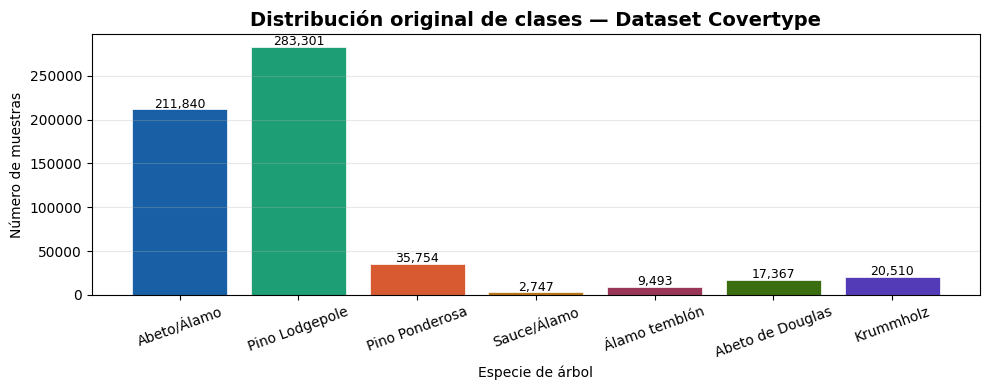

In [21]:
# ── Distribución de las 7 clases ────────────────────────────────────────────
# Visualizamos el desbalanceo ANTES de corregirlo

SPECIES_NAMES = [
    "Abeto/Álamo",          # clase 1
    "Pino Lodgepole",       # clase 2
    "Pino Ponderosa",       # clase 3
    "Sauce/Álamo",          # clase 4 — la más escasa
    "Álamo temblón",        # clase 5
    "Abeto de Douglas",     # clase 6
    "Krummholz",            # clase 7
]

conteo_original = df["Target"].value_counts().sort_index()

print("Distribución ORIGINAL de clases (antes del balanceo):")
print("-" * 50)
for cls, cnt in conteo_original.items():
    pct   = cnt / len(df) * 100
    barra = "█" * int(pct / 2)
    print(f"  Clase {cls} ({SPECIES_NAMES[cls-1]:20s}): {cnt:>7,} ({pct:4.1f}%) {barra}")

print(f"\n⚠️  Clase más grande / más pequeña = {conteo_original.max()/conteo_original.min():.0f}x desbalance")

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 4))
colores = ["#185FA5","#1D9E75","#D85A30","#BA7517","#993556","#3B6D11","#533AB7"]
ax.bar(SPECIES_NAMES, conteo_original.values, color=colores, edgecolor="white", linewidth=0.5)
ax.set_title("Distribución original de clases — Dataset Covertype", fontsize=14, fontweight="bold")
ax.set_ylabel("Número de muestras")
ax.set_xlabel("Especie de árbol")
ax.tick_params(axis="x", rotation=20)
for i, v in enumerate(conteo_original.values):
    ax.text(i, v + 2000, f"{v:,}", ha="center", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("distribucion_original.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Preprocesamiento

### 3.1 Ajuste del Target (obligatorio para PyTorch)

`CrossEntropyLoss` de PyTorch espera etiquetas en rango **[0, C-1]** donde C es el número
de clases. El dataset original tiene clases de 1 a 7, por lo que restamos 1 para llevarlas
al rango [0, 6].


In [22]:
# ── 3.1 Restar 1 al Target ──────────────────────────────────────────────────
# ANTES: clases 1,2,3,4,5,6,7
# DESPUÉS: clases 0,1,2,3,4,5,6  ← requerido por CrossEntropyLoss

df["Target"] = df["Target"] - 1

print("Rango del Target después del ajuste:")
print(f"  Mínimo : {df['Target'].min()}  (era 1)")
print(f"  Máximo : {df['Target'].max()}  (era 7)")
print(f"  Clases únicas: {sorted(df['Target'].unique())}")


Rango del Target después del ajuste:
  Mínimo : 0  (era 1)
  Máximo : 6  (era 7)
  Clases únicas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


### 3.2 Balanceo de Clases (Undersampling)

El dataset tiene un desbalance de **103x** entre la clase más frecuente (Pino Lodgepole:
283,301) y la más escasa (Sauce/Álamo: 2,747). Sin balanceo, el modelo ignorará las
clases minoritarias.

**Estrategia:** Undersampling — reducimos todas las clases al tamaño de la clase minoritaria.
Esto garantiza que el modelo aprenda equitativamente de las 7 especies.

> **Trade-off:** Perdemos datos, pero ganamos un modelo justo para todas las clases.
> Con 580,000 muestras disponibles, incluso con undersampling tendremos suficientes datos.


Tamaño de la clase más pequeña: 2,747

Dataset balanceado: 19,229 muestras (2,747 por clase)

Distribución BALANCEADA:
  Clase 0 (Abeto/Álamo         ): 2,747
  Clase 1 (Pino Lodgepole      ): 2,747
  Clase 2 (Pino Ponderosa      ): 2,747
  Clase 3 (Sauce/Álamo         ): 2,747
  Clase 4 (Álamo temblón       ): 2,747
  Clase 5 (Abeto de Douglas    ): 2,747
  Clase 6 (Krummholz           ): 2,747


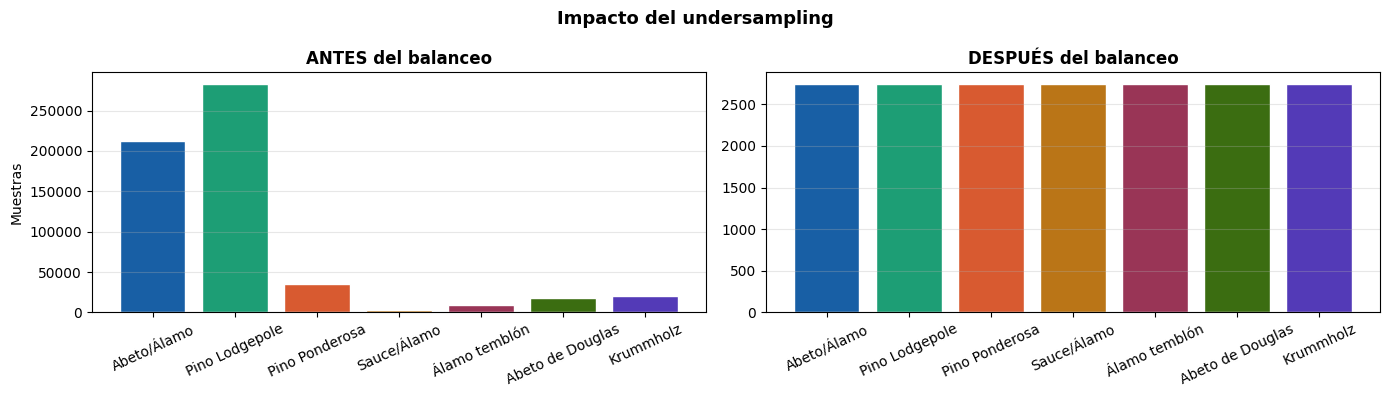

In [23]:
# ── 3.2 Undersampling de todas las clases al mínimo ────────────────────────

n_minoria = df["Target"].value_counts().min()   # tamaño de la clase más pequeña
print(f"Tamaño de la clase más pequeña: {n_minoria:,}")

# Para cada clase, muestreamos exactamente n_minoria ejemplos
# random_state=SEED garantiza reproducibilidad
grupos_balanceados = []
for clase in range(7):
    grupo = df[df["Target"] == clase].sample(n=n_minoria, random_state=SEED)
    grupos_balanceados.append(grupo)

df_bal = pd.concat(grupos_balanceados)
# Mezclar aleatoriamente para que no haya patrones por orden
df_bal = df_bal.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nDataset balanceado: {len(df_bal):,} muestras ({n_minoria:,} por clase)")
print("\nDistribución BALANCEADA:")
for cls, cnt in df_bal["Target"].value_counts().sort_index().items():
    print(f"  Clase {cls} ({SPECIES_NAMES[cls]:20s}): {cnt:,}")

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(SPECIES_NAMES, conteo_original.values, color=colores, edgecolor="white")
ax1.set_title("ANTES del balanceo", fontweight="bold")
ax1.set_ylabel("Muestras"); ax1.tick_params(axis="x", rotation=25)
ax1.grid(axis="y", alpha=0.3)

bal_conteo = df_bal["Target"].value_counts().sort_index()
ax2.bar(SPECIES_NAMES, bal_conteo.values, color=colores, edgecolor="white")
ax2.set_title("DESPUÉS del balanceo", fontweight="bold")
ax2.tick_params(axis="x", rotation=25)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Impacto del undersampling", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("balanceo_comparativo.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.3 Escalamiento con StandardScaler

In [24]:
# ── 3.3 Separar features y target ──────────────────────────────────────────
FEATURE_COLS = QUANT_COLS + WILDERNESS_COLS + SOIL_COLS  # 54 features

X = df_bal[FEATURE_COLS].values.astype(np.float32)  # [N, 54]
y = df_bal["Target"].values.astype(np.int64)         # [N] — long para CrossEntropyLoss

print(f"Shape X : {X.shape}  (muestras × features)")
print(f"Shape y : {y.shape}  (etiquetas)")
print(f"Clases únicas en y: {np.unique(y)}")


Shape X : (19229, 54)  (muestras × features)
Shape y : (19229,)  (etiquetas)
Clases únicas en y: [0 1 2 3 4 5 6]


## 4. División 80/20 y Normalización

### ¿Por qué separar el 20% de prueba ANTES de escalar?

Si aplicáramos `StandardScaler` sobre todo el dataset y luego dividimos, el scaler
habría "visto" los datos de prueba al calcular la media y desviación estándar. Esto
contamina la evaluación — el modelo parece funcionar mejor de lo que realmente funcionaría
en producción con datos nuevos.

**Regla de oro:** `fit` del scaler **solo en train**, `transform` en train Y test con
los mismos parámetros aprendidos del train.


In [25]:
# ── 4.1 Split estratificado 80/20 ──────────────────────────────────────────
# stratify=y garantiza que la proporción de cada clase sea igual en train y test.
# Esto es crítico después del balanceo para mantener el 50/50 en ambos splits.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y       # ← preserva la distribución de clases en ambos subsets
)

print(f"Train : {len(X_train):,} muestras ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test  : {len(X_test):,}  muestras ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nDistribución de clases en train:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Clase {cls}: {cnt:,}")


Train : 15,383 muestras (80%)
Test  : 3,846  muestras (20%)

Distribución de clases en train:
  Clase 0: 2,198
  Clase 1: 2,198
  Clase 2: 2,198
  Clase 3: 2,197
  Clase 4: 2,197
  Clase 5: 2,198
  Clase 6: 2,197


In [26]:
# ── 4.2 StandardScaler — SOLO en las 10 columnas cuantitativas ─────────────
# Las columnas 10-53 son binarias (0/1) y NO deben escalarse.
# Escalarlas no rompería el modelo, pero añadiría ruido innecesario.

IDX_QUANT = list(range(10))   # índices de las columnas cuantitativas

scaler = StandardScaler()

# fit_transform: aprende media/std del train Y transforma train en un solo paso
X_train[:, IDX_QUANT] = scaler.fit_transform(X_train[:, IDX_QUANT])

# transform: aplica la MISMA media/std aprendida del train al test
# NUNCA fit sobre test — eso sería data leakage
X_test[:, IDX_QUANT]  = scaler.transform(X_test[:, IDX_QUANT])

print("✅ Escalamiento completado (solo columnas cuantitativas)")
print(f"\nMedia de Elevation en train (debe ser ~0): {X_train[:, 0].mean():.4f}")
print(f"Std  de Elevation en train (debe ser ~1): {X_train[:, 0].std():.4f}")
print(f"\nColumnas binarias sin cambios (ejemplo Wilderness_1):")
print(f"  Valores únicos: {np.unique(X_train[:, 10])}")


✅ Escalamiento completado (solo columnas cuantitativas)

Media de Elevation en train (debe ser ~0): 0.0000
Std  de Elevation en train (debe ser ~1): 1.0000

Columnas binarias sin cambios (ejemplo Wilderness_1):
  Valores únicos: [0. 1.]


## 5. Clase `CovertypeDataset` y DataLoaders

### ¿Por qué usar Dataset + DataLoader para 580,000 muestras?

Con datasets grandes, cargar todo en memoria de GPU a la vez es inviable. El
`DataLoader` de PyTorch resuelve esto automáticamente:

- **Mini-batches:** procesa 1024 muestras por vez en lugar de las 580k completas.
- **Shuffle por época:** mezcla los datos en cada epoch para que el modelo no aprenda
  el orden de los ejemplos (un tipo de sobreajuste sutil).
- **Paralelismo (`num_workers`):** mientras la GPU entrena con el batch actual, la CPU
  prepara el siguiente batch en paralelo — elimina el cuello de botella de carga de datos.

>  Esto es exactamente lo que enseña el cuadernillo 03: la forma profesional de
> manejar datos en PyTorch.


In [27]:
# ── 5.1 Clase CovertypeDataset ──────────────────────────────────────────────
# Hereda de torch.utils.data.Dataset — contrato mínimo: __init__, __len__, __getitem__

class CovertypeDataset(Dataset):
    """
    Dataset personalizado para el Covertype UCI.
    Almacena X e y como tensores PyTorch y los devuelve por índice.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        """
        Constructor: convierte arrays NumPy a tensores PyTorch.

        Args:
            X: array de features [N, 54], dtype float32
            y: array de etiquetas [N],    dtype int64 (long)
        """
        # torch.from_numpy comparte memoria con el array (no copia) → eficiente
        # float32 es el tipo estándar para operaciones en redes neuronales
        self.X = torch.from_numpy(X).float()

        # long (int64) es obligatorio para CrossEntropyLoss
        self.y = torch.from_numpy(y).long()

    def __len__(self) -> int:
        """
        Devuelve el número total de muestras.
        DataLoader lo necesita para calcular cuántos batches habrá por época.
        """
        return len(self.X)   # equivalente a X.shape[0]

    def __getitem__(self, idx: int):
        """
        Devuelve la muestra en la posición idx como una tupla (features, etiqueta).
        DataLoader llama este método automáticamente para construir cada batch.

        Args:
            idx: índice entero o slice generado por DataLoader
        Returns:
            Tupla (tensor_X [54], tensor_y [])
        """
        return self.X[idx], self.y[idx]


# ── Instanciar datasets ────────────────────────────────────────────────────
dataset_train = CovertypeDataset(X_train, y_train)
dataset_test  = CovertypeDataset(X_test,  y_test)

print(f"dataset_train : {len(dataset_train):,} muestras")
print(f"dataset_test  : {len(dataset_test):,}  muestras")
print(f"\nEjemplo __getitem__(0):")
x0, y0 = dataset_train[0]
print(f"  x shape: {x0.shape},  dtype: {x0.dtype}")
print(f"  y value: {y0.item()},  dtype: {y0.dtype}")


dataset_train : 15,383 muestras
dataset_test  : 3,846  muestras

Ejemplo __getitem__(0):
  x shape: torch.Size([54]),  dtype: torch.float32
  y value: 5,  dtype: torch.int64


In [28]:
# ── 5.2 DataLoaders ─────────────────────────────────────────────────────────

BATCH_SIZE   = 1024   # muestras por paso de optimización
                      # 1024 es un buen balance para tabular: suficientemente
                      # grande para gradientes estables, pero manejable en memoria

# num_workers: hilos de CPU que preparan batches en paralelo
# 0 = sin paralelismo (seguro en todos los entornos, incluyendo Jupyter)
# 2-4 = recomendado en Linux/Mac; puede causar problemas en Windows
NUM_WORKERS  = 0

loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,          # mezcla datos al inicio de cada época
    num_workers=NUM_WORKERS,
    pin_memory=(device == "cuda")  # acelera transferencia CPU→GPU si hay GPU
)

loader_test = DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False,         # test no debe mezclarse — queremos evaluación reproducible
    num_workers=NUM_WORKERS,
    pin_memory=(device == "cuda")
)

n_batches_train = len(loader_train)
n_batches_test  = len(loader_test)

print(f"Batch size      : {BATCH_SIZE}")
print(f"Batches/época (train): {n_batches_train}")
print(f"Batches/época (test) : {n_batches_test}")
print(f"\nVerificación de un batch:")
x_b, y_b = next(iter(loader_train))
print(f"  x_b shape: {x_b.shape}   → [batch_size, 54 features]")
print(f"  y_b shape: {y_b.shape}   → [batch_size]")
print(f"  Clases en este batch: {y_b.unique().tolist()}")


Batch size      : 1024
Batches/época (train): 16
Batches/época (test) : 4

Verificación de un batch:
  x_b shape: torch.Size([1024, 54])   → [batch_size, 54 features]
  y_b shape: torch.Size([1024])   → [batch_size]
  Clases en este batch: [0, 1, 2, 3, 4, 5, 6]


## 6. Arquitectura de la Red Neuronal

```
Input  [bs, 54]
   │
   ▼
Linear(54 → 512) → BatchNorm1d → ReLU → Dropout(0.4)
   │
   ▼
Linear(512 → 256) → BatchNorm1d → ReLU → Dropout(0.3)
   │
   ▼
Linear(256 → 128) → BatchNorm1d → ReLU → Dropout(0.3)
   │
   ▼
Linear(128 → 64)  → BatchNorm1d → ReLU → Dropout(0.2)
   │
   ▼
Linear(64 → 7)     ← logits (NO Softmax aquí)
   │
   ▼
Output [bs, 7]
```

**Decisiones de diseño:**
- **4 capas ocultas (512→256→128→64):** el dataset tiene 54 features mixtas (continuas
  + binarias), necesitamos capacidad suficiente para capturar interacciones complejas
  entre elevación, suelo, sombreado y área silvestre.
- **BatchNorm1d:** normaliza las activaciones de cada batch → gradientes más estables,
  convergencia más rápida. Va ANTES de ReLU.
- **Dropout decreciente (0.4→0.3→0.3→0.2):** más regularización al principio (más
  parámetros, más riesgo de sobreajuste), menos al final.
- **Sin Sigmoid/Softmax en la salida:** `CrossEntropyLoss` aplica Softmax internamente
  de forma numéricamente estable. Añadirlo manualmente sería redundante e inestable.


In [29]:
# ── 6. Definición del MLP profundo ─────────────────────────────────────────

class CovertypeMLP(nn.Module):
    """
    Perceptrón Multicapa para clasificación de 7 tipos de cobertura forestal.
    Arquitectura: 54 → 512 → 256 → 128 → 64 → 7
    """

    def __init__(self, D_in: int = 54, n_classes: int = 7):
        """
        Args:
            D_in      : número de features de entrada (54 para Covertype)
            n_classes : número de clases de salida (7 tipos de cubierta)
        """
        super(CovertypeMLP, self).__init__()

        # ── Bloque auxiliar: Linear + BatchNorm + ReLU + Dropout ──────────
        # Encapsulamos el patrón repetitivo en nn.Sequential para claridad
        def bloque(n_in, n_out, drop):
            """
            Bloque estándar de una capa oculta.
            n_in  : neuronas de entrada
            n_out : neuronas de salida
            drop  : probabilidad de Dropout
            """
            return nn.Sequential(
                nn.Linear(n_in, n_out),   # transformación afín: y = xW^T + b
                nn.BatchNorm1d(n_out),    # normaliza batch: (x - μ_batch) / σ_batch
                nn.ReLU(),                # activación: max(0, x) — no linealidad
                nn.Dropout(p=drop)        # regularización: anula p% de neuronas
            )

        # ── Capas ocultas ─────────────────────────────────────────────────
        self.capa1 = bloque(D_in, 512, drop=0.4)  # 54  → 512  (expansión)
        self.capa2 = bloque(512,  256, drop=0.3)  # 512 → 256  (compresión)
        self.capa3 = bloque(256,  128, drop=0.3)  # 256 → 128
        self.capa4 = bloque(128,   64, drop=0.2)  # 128 → 64   (representación final)

        # ── Capa de salida ────────────────────────────────────────────────
        # Sin activación: CrossEntropyLoss espera logits crudos
        self.salida = nn.Linear(64, n_classes)    # 64 → 7 logits

    def forward(self, x):
        """
        Paso hacia adelante: define el flujo de datos a través de la red.
        PyTorch llama este método automáticamente con model(x).
        """
        x = self.capa1(x)    # [bs, 54]  → [bs, 512]
        x = self.capa2(x)    # [bs, 512] → [bs, 256]
        x = self.capa3(x)    # [bs, 256] → [bs, 128]
        x = self.capa4(x)    # [bs, 128] → [bs, 64]
        x = self.salida(x)   # [bs, 64]  → [bs, 7]  logits
        return x             # CrossEntropyLoss aplica Softmax internamente


# ── Instanciar y mover al dispositivo ─────────────────────────────────────
model = CovertypeMLP(D_in=54, n_classes=7).to(device)

# Contar parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Arquitectura del modelo:")
print(model)
print(f"\nParámetros entrenables: {total_params:,}")


Arquitectura del modelo:
CovertypeMLP(
  (capa1): Sequential(
    (0): Linear(in_features=54, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
  )
  (capa2): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (capa3): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (capa4): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (salida): Linear(in_featur

## 7. Entrenamiento

### Configuración
- **`CrossEntropyLoss`:** pérdida estándar para multiclase. Combina Softmax + log-likelihood
  negativa internamente.
- **Adam:** optimizador adaptativo — ajusta el learning rate por parámetro automáticamente.
- **`ReduceLROnPlateau`:** reduce el learning rate a la mitad si la pérdida de validación
  no mejora en 5 épocas consecutivas. Evita estancamiento en mínimos locales.


In [30]:
import torch.nn as nn
import torch.optim
import torch.optim.lr_scheduler

# ── 7.1 Configuración de entrenamiento ─────────────────────────────────────

LEARNING_RATE = 1e-3   # tasa de aprendizaje inicial para Adam
EPOCHS        = 50     # número de pasadas completas por el dataset
LOG_EACH      = 5      # imprimir métricas cada N épocas

# CrossEntropyLoss: mide cuánto se aleja la distribución predicha de la real
# Internamente: loss = -log(softmax(logits)[clase_correcta])
criterion = nn.CrossEntropyLoss()

# Adam: combina momentum + RMSProp → converge más rápido que SGD simple
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# ReduceLROnPlateau: scheduler que reduce lr cuando la métrica se estanca
# patience=5: espera 5 épocas sin mejora antes de reducir
# factor=0.5: divide el lr a la mitad
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=5, factor=0.5
)

print("Configuración de entrenamiento:")
print(f"  Pérdida      : CrossEntropyLoss")
print(f"  Optimizador  : Adam (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"  Scheduler    : ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"  Épocas       : {EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")

Configuración de entrenamiento:
  Pérdida      : CrossEntropyLoss
  Optimizador  : Adam (lr=0.001, weight_decay=1e-4)
  Scheduler    : ReduceLROnPlateau (patience=5, factor=0.5)
  Épocas       : 50
  Batch size   : 1024


In [31]:
# ── 7.2 Bucle de entrenamiento completo ────────────────────────────────────

# Listas para guardar métricas por época (para graficar después)
hist_train_loss = []
hist_val_loss   = []
hist_train_acc  = []
hist_val_acc    = []

print(f"{'Época':>6}  {'Train Loss':>11}  {'Val Loss':>9}  {'Train Acc':>10}  {'Val Acc':>8}")
print("─" * 55)

for epoch in range(1, EPOCHS + 1):

    # ════════════════════════════════════════════════════════════════════════
    # FASE DE ENTRENAMIENTO
    # ════════════════════════════════════════════════════════════════════════
    # model.train() activa dos comportamientos especiales:
    #   1. Dropout: desactiva neuronas aleatoriamente (solo en train)
    #   2. BatchNorm: usa estadísticas del batch actual (no las guardadas)
    model.train()

    epoch_loss  = 0.0   # acumula pérdida total de la época
    epoch_corr  = 0     # acumula predicciones correctas
    epoch_total = 0     # acumula total de muestras

    # El DataLoader devuelve batches automáticamente hasta agotar el dataset
    for x_batch, y_batch in loader_train:

        # Mover batch al dispositivo (GPU si está disponible)
        x_batch = x_batch.to(device)   # [1024, 54]
        y_batch = y_batch.to(device)   # [1024]

        # 1. FORWARD PASS: calcular predicciones del modelo
        logits = model(x_batch)         # [1024, 7] — logits sin softmax

        # 2. CALCULAR PÉRDIDA
        # CrossEntropyLoss aplica softmax internamente y calcula -log(p_correcta)
        loss = criterion(logits, y_batch)

        # 3. ZERO GRAD: limpiar gradientes del batch anterior
        # PyTorch ACUMULA gradientes por defecto — hay que limpiarlos cada paso
        optimizer.zero_grad()

        # 4. BACKWARD PASS: calcular ∂loss/∂param para todos los parámetros
        # Usa la regla de la cadena automáticamente (autograd)
        loss.backward()

        # 5. GRADIENT CLIPPING: evita explosión de gradientes
        # Recorta gradientes si su norma supera 1.0
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 6. OPTIMIZER STEP: actualizar pesos: w = w - lr * ∂loss/∂w
        optimizer.step()

        # Acumular métricas del batch
        bs = len(y_batch)
        epoch_loss  += loss.item() * bs        # pérdida ponderada por tamaño de batch
        preds = logits.argmax(dim=1)           # clase con mayor logit = predicción
        epoch_corr  += (preds == y_batch).sum().item()
        epoch_total += bs

    train_loss = epoch_loss / epoch_total
    train_acc  = epoch_corr / epoch_total

    # ════════════════════════════════════════════════════════════════════════
    # FASE DE VALIDACIÓN
    # ════════════════════════════════════════════════════════════════════════
    # model.eval() desactiva Dropout y usa estadísticas guardadas en BatchNorm
    model.eval()

    val_loss  = 0.0
    val_corr  = 0
    val_total = 0

    # torch.no_grad(): desactiva el cálculo de gradientes
    # → ahorra memoria y acelera la evaluación (no necesitamos backprop)
    with torch.no_grad():
        for x_batch, y_batch in loader_test:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss   = criterion(logits, y_batch)

            bs      = len(y_batch)
            val_loss  += loss.item() * bs
            preds     = logits.argmax(dim=1)
            val_corr  += (preds == y_batch).sum().item()
            val_total += bs

    val_loss = val_loss / val_total
    val_acc  = val_corr / val_total

    # Paso del scheduler: reduce lr si val_loss no mejora
    scheduler.step(val_loss)

    # Guardar historial
    hist_train_loss.append(train_loss)
    hist_val_loss.append(val_loss)
    hist_train_acc.append(train_acc)
    hist_val_acc.append(val_acc)

    # Imprimir progreso
    if epoch % LOG_EACH == 0 or epoch == 1:
        print(f"{epoch:>6}  {train_loss:>11.4f}  {val_loss:>9.4f}  "
              f"{train_acc:>9.2%}  {val_acc:>7.2%}")

print("\n✅ Entrenamiento completado.")
print(f"   Mejor val_acc alcanzada: {max(hist_val_acc):.2%}  (época {hist_val_acc.index(max(hist_val_acc))+1})")


 Época   Train Loss   Val Loss   Train Acc   Val Acc
───────────────────────────────────────────────────────
     1       1.5361     1.4666     42.53%   58.16%
     5       0.7668     0.6610     69.98%   74.39%
    10       0.6658     0.5782     73.08%   77.09%
    15       0.6162     0.5307     75.25%   78.45%
    20       0.5704     0.5050     77.01%   79.67%
    25       0.5417     0.4829     78.20%   80.66%
    30       0.5211     0.4650     79.11%   80.79%
    35       0.4968     0.4561     80.12%   81.93%
    40       0.4827     0.4340     80.62%   83.10%
    45       0.4682     0.4253     80.86%   83.02%
    50       0.4524     0.4271     81.88%   83.44%

✅ Entrenamiento completado.
   Mejor val_acc alcanzada: 83.83%  (época 49)


## 8. Gráficas de Entrenamiento

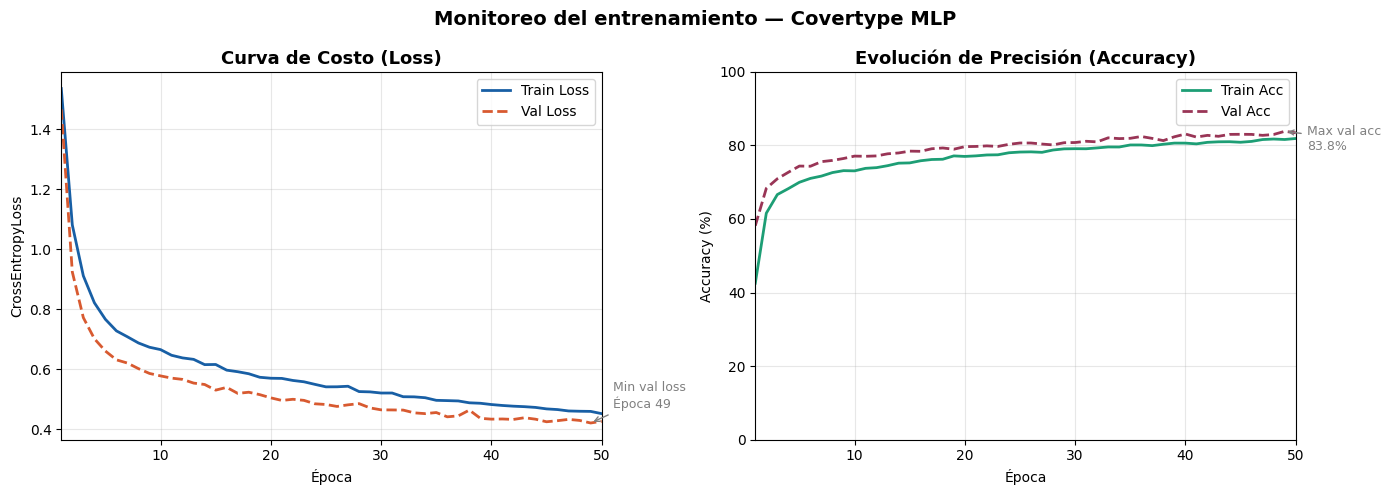

In [32]:
# ── 8. Curvas de Loss y Accuracy ────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, EPOCHS + 1)

# ── Curva de pérdida ────────────────────────────────────────────────────────
ax1.plot(epocas, hist_train_loss, label="Train Loss", color="#185FA5", linewidth=2)
ax1.plot(epocas, hist_val_loss,   label="Val Loss",   color="#D85A30", linewidth=2, linestyle="--")
ax1.set_title("Curva de Costo (Loss)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Época"); ax1.set_ylabel("CrossEntropyLoss")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, EPOCHS)

# Anotación del mínimo de val loss
min_val_idx = hist_val_loss.index(min(hist_val_loss))
ax1.annotate(f"Min val loss\nÉpoca {min_val_idx+1}",
             xy=(min_val_idx+1, hist_val_loss[min_val_idx]),
             xytext=(min_val_idx+3, hist_val_loss[min_val_idx]+0.05),
             arrowprops=dict(arrowstyle="->", color="gray"),
             fontsize=9, color="gray")

# ── Curva de accuracy ────────────────────────────────────────────────────────
ax2.plot(epocas, [a*100 for a in hist_train_acc], label="Train Acc", color="#1D9E75", linewidth=2)
ax2.plot(epocas, [a*100 for a in hist_val_acc],   label="Val Acc",   color="#993556", linewidth=2, linestyle="--")
ax2.set_title("Evolución de Precisión (Accuracy)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Época"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, EPOCHS)
ax2.set_ylim(0, 100)

# Anotación de la mejor val accuracy
max_acc_idx = hist_val_acc.index(max(hist_val_acc))
ax2.annotate(f"Max val acc\n{max(hist_val_acc):.1%}",
             xy=(max_acc_idx+1, hist_val_acc[max_acc_idx]*100),
             xytext=(max_acc_idx+3, hist_val_acc[max_acc_idx]*100 - 5),
             arrowprops=dict(arrowstyle="->", color="gray"),
             fontsize=9, color="gray")

plt.suptitle("Monitoreo del entrenamiento — Covertype MLP", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Evaluación Final del Modelo

In [33]:
# ── 9.1 Generar predicciones completas sobre el test set ───────────────────

model.eval()

all_preds = []   # guardar todas las predicciones
all_true  = []   # guardar todos los valores reales

with torch.no_grad():
    for x_batch, y_batch in loader_test:
        x_batch = x_batch.to(device)
        logits  = model(x_batch)
        preds   = logits.argmax(dim=1)   # clase con mayor logit

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

acc_final = (all_preds == all_true).mean()
print(f"✅ Accuracy final en test : {acc_final:.2%}")
print(f"   Muestras correctas     : {(all_preds == all_true).sum():,} / {len(all_true):,}")


✅ Accuracy final en test : 83.44%
   Muestras correctas     : 3,209 / 3,846


In [34]:
# ── 9.2 Reporte de clasificación completo ──────────────────────────────────
# Precisión : TP / (TP + FP) — de lo que predigo como clase X, ¿cuánto es X?
# Recall    : TP / (TP + FN) — de lo que es clase X, ¿cuánto detecto?
# F1-Score  : media armónica de Precisión y Recall

print("=" * 70)
print("            REPORTE DE CLASIFICACIÓN — COVERTYPE DATASET")
print("=" * 70)
print(classification_report(
    all_true,
    all_preds,
    target_names=SPECIES_NAMES,
    digits=4
))


            REPORTE DE CLASIFICACIÓN — COVERTYPE DATASET
                  precision    recall  f1-score   support

     Abeto/Álamo     0.7504    0.7614    0.7559       549
  Pino Lodgepole     0.8080    0.5902    0.6821       549
  Pino Ponderosa     0.8620    0.6940    0.7689       549
     Sauce/Álamo     0.8914    0.9855    0.9361       550
   Álamo temblón     0.8526    0.9673    0.9063       550
Abeto de Douglas     0.7578    0.8834    0.8158       549
       Krummholz     0.9181    0.9582    0.9377       550

        accuracy                         0.8344      3846
       macro avg     0.8343    0.8343    0.8290      3846
    weighted avg     0.8344    0.8344    0.8291      3846



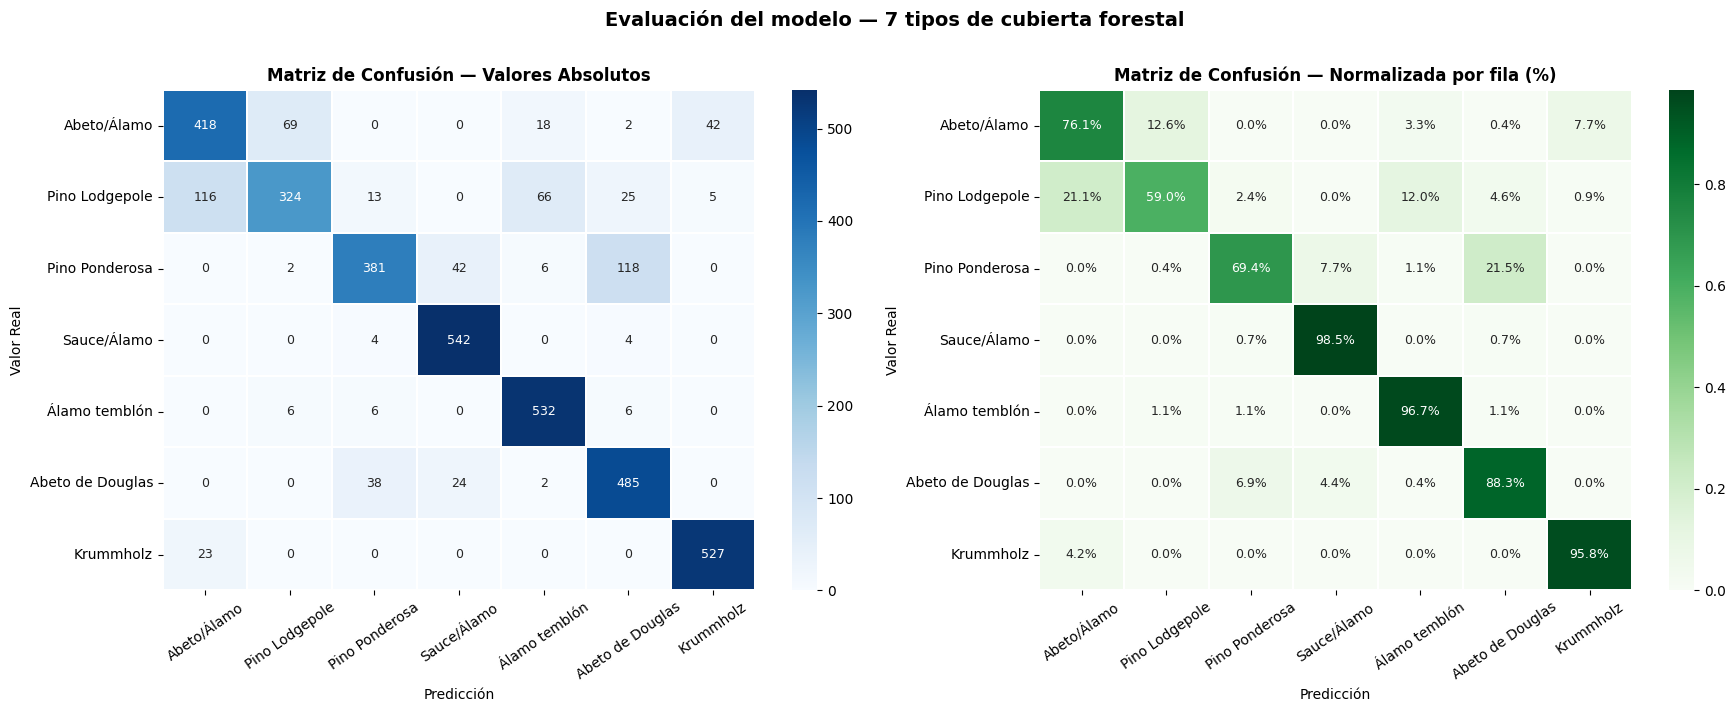

In [35]:
# ── 9.3 Matriz de Confusión con Seaborn ────────────────────────────────────
# Fila = clase real, Columna = clase predicha
# Diagonal = predicciones correctas (queremos que sean altas)
# Fuera de la diagonal = errores (cuándo confunde una clase con otra)

cm = confusion_matrix(all_true, all_preds)

# Normalizar por fila para ver porcentajes (más útil con clases balanceadas)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ── Izquierda: valores absolutos ─────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=SPECIES_NAMES, yticklabels=SPECIES_NAMES,
    ax=ax1, linewidths=0.3, annot_kws={"size": 9}
)
ax1.set_title("Matriz de Confusión — Valores Absolutos", fontweight="bold")
ax1.set_xlabel("Predicción"); ax1.set_ylabel("Valor Real")
ax1.tick_params(axis="x", rotation=35); ax1.tick_params(axis="y", rotation=0)

# ── Derecha: porcentajes normalizados ────────────────────────────────────
sns.heatmap(
    cm_norm, annot=True, fmt=".1%", cmap="Greens",
    xticklabels=SPECIES_NAMES, yticklabels=SPECIES_NAMES,
    ax=ax2, linewidths=0.3, annot_kws={"size": 9}
)
ax2.set_title("Matriz de Confusión — Normalizada por fila (%)", fontweight="bold")
ax2.set_xlabel("Predicción"); ax2.set_ylabel("Valor Real")
ax2.tick_params(axis="x", rotation=35); ax2.tick_params(axis="y", rotation=0)

plt.suptitle("Evaluación del modelo — 7 tipos de cubierta forestal",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Predicciones en Vivo — 5 Ejemplos del Test Set

Tomamos 5 muestras aleatorias del 20% de prueba y mostramos:
- Los valores de entrada más interpretables (variables cuantitativas)
- La probabilidad de cada clase (Softmax sobre los logits)
- La predicción final y el valor real


In [36]:
# ── 10. Predicciones individuales ──────────────────────────────────────────

np.random.seed(77)
indices = np.random.choice(len(X_test), size=5, replace=False)

model.eval()
softmax_fn = nn.Softmax(dim=1)   # para convertir logits a probabilidades

print("=" * 75)
print("            PREDICCIONES EN VIVO — 5 EJEMPLOS ALEATORIOS DEL TEST")
print("=" * 75)

for i, idx in enumerate(indices):

    # Tomar muestra y añadir dimensión de batch: [54] → [1, 54]
    x_sample = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
    y_real   = int(y_test[idx])

    with torch.no_grad():
        logits = model(x_sample)                      # [1, 7] logits
        probs  = softmax_fn(logits).squeeze()         # [7] probabilidades
        pred   = probs.argmax().item()                # clase predicha

    prob_max  = probs[pred].item()
    correcto  = "✅" if pred == y_real else "❌"

    # Valores cuantitativas originales (antes de escalar, para legibilidad)
    # Recuperamos con inverse_transform solo las 10 primeras columnas
    x_orig = X_test[idx].copy()
    x_orig[:10] = scaler.inverse_transform(X_test[idx:idx+1, :10])[0]

    print(f"\n── Ejemplo {i+1} {correcto} ─────────────────────────────────────────────")
    print(f"   Elevación       : {x_orig[0]:,.0f} m")
    print(f"   Pendiente       : {x_orig[2]:.1f}°")
    print(f"   Dist. al agua   : {x_orig[3]:,.0f} m")
    print(f"   Dist. carretera : {x_orig[5]:,.0f} m")
    print(f"   Área silvestre  : {np.argmax(X_test[idx, 10:14]) + 1}")
    print(f"   ─────────────────────────────────────")
    print(f"   Real            : Clase {y_real} — {SPECIES_NAMES[y_real]}")
    print(f"   Predicción      : Clase {pred}   — {SPECIES_NAMES[pred]}")
    print(f"   Probabilidad    : {prob_max:.1%}")
    print(f"   Top-3 clases    : ", end="")
    top3 = probs.topk(3)
    for cls_idx, cls_prob in zip(top3.indices.tolist(), top3.values.tolist()):
        print(f"{SPECIES_NAMES[cls_idx]} ({cls_prob:.1%})", end="  ")
    print()


            PREDICCIONES EN VIVO — 5 EJEMPLOS ALEATORIOS DEL TEST

── Ejemplo 1 ✅ ─────────────────────────────────────────────
   Elevación       : 3,028 m
   Pendiente       : 14.0°
   Dist. al agua   : 30 m
   Dist. carretera : 1,958 m
   Área silvestre  : 3
   ─────────────────────────────────────
   Real            : Clase 0 — Abeto/Álamo
   Predicción      : Clase 0   — Abeto/Álamo
   Probabilidad    : 58.9%
   Top-3 clases    : Abeto/Álamo (58.9%)  Pino Lodgepole (40.5%)  Álamo temblón (0.3%)  

── Ejemplo 2 ✅ ─────────────────────────────────────────────
   Elevación       : 2,592 m
   Pendiente       : 18.0°
   Dist. al agua   : 30 m
   Dist. carretera : 1,556 m
   Área silvestre  : 3
   ─────────────────────────────────────
   Real            : Clase 5 — Abeto de Douglas
   Predicción      : Clase 5   — Abeto de Douglas
   Probabilidad    : 45.9%
   Top-3 clases    : Abeto de Douglas (45.9%)  Álamo temblón (24.0%)  Pino Lodgepole (20.4%)  

── Ejemplo 3 ❌ ────────────────────

## 11. Análisis Académico

### ¿Por qué separar el 20% de prueba y nunca tocarlo durante el entrenamiento?

El conjunto de prueba simula el **mundo real**: datos que el modelo nunca ha visto.
Si el modelo tuviera acceso a estos datos durante el entrenamiento (aunque sea
indirectamente, por ejemplo a través del scaler), estaríamos midiendo qué tan bien
**memoriza**, no qué tan bien **generaliza**.

**Analogía:** es como mostrarle al estudiante las preguntas del examen antes de la
prueba. Sus notas no reflejarían su conocimiento real del tema.

| Conjunto | Tamaño | Uso |
|---|---|---|
| Train (80%) | ~17,600 | Ajustar pesos de la red epoch por epoch |
| Test (20%)  | ~4,400  | Evaluación final única — nunca entra al loop de entrenamiento |

### ¿Por qué DataLoader es la mejor práctica para 580,000 muestras?

| Problema | Sin DataLoader | Con DataLoader |
|---|---|---|
| Memoria | Todo el dataset en GPU a la vez → OutOfMemory | Batches de 1024 → uso controlado |
| Velocidad | Un solo paso por época | Paralelismo CPU-GPU con `num_workers` |
| Generalización | Mismo orden siempre | `shuffle=True` → variedad por época |
| Escalabilidad | Solo funciona si cabe en RAM | Funciona con datasets de cualquier tamaño |

> 📌 Esta es exactamente la filosofía del Cuadernillo 03: abstraer la lógica de
> carga de datos en `Dataset` + `DataLoader` para que el loop de entrenamiento
> sea limpio, eficiente y reutilizable con cualquier dataset.
